In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from datetime import date
import collections
import datetime
import os
import xarray as xr
from cycler import cycler
import matplotlib.patches as mpatches

In [7]:
scenarios = ['ssp126','ssp245','ssp370','ssp585']

modelnames = ['BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'GFDL-ESM4', 
                  'INM-CM4-8', 'INM-CM5-0', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'NorESM2-MM']

basins = {'RHINE':'6242', 'RHONE':'6243','PO':'6241', 'DANUBE':'6202', 'TITICACA':'3912', 'SANTA':'3425', 
            'OCONA':'3418', 'MAJES':'3416', 'MAGDALENA':'3227', 'AMAZON':'3203', 'YELCHO':'3429', 
            'VALDIVIA':'3428', 'SERRANO':'3426', 'RAPEL':'3423', 'PUELO':'3422', 'PASCUA':'3420', 
            'PALENA':'3419', 'HUASCO':'3412', 'COPIAPO':'3409', 'CISNES':'3408', 'BIOBIO':'3405', 'BAKER':'3404',
            'AZOPARDO':'3403', 'AISEN':'3401', 'SANTA CRUZ':'3244', 'NEGRO':'3232', 'COLORADO':'3212', 
            'CHICO':'3209', 'TORNEALVEN':'6255', 'THJORSA':'6254', 'OLFUSA':'6237', 'LULEALVEN':'6227', 
            'KUBAN':'6223', 'KALIXALVEN':'6219', 'GLOMAA':'6213', 'DRAMSELVA':'6209', 'SVARTA':'6110', 
            'LAGARFLJOT':'6104', 'JOKULSA A FJOLLUM':'6101', 'CLUTHA':'5406', 'YUKON':'4435', 'TAKU':'4431', 
             'SUSITNA':'4430','STIKINE':'4428', 'SKEENA':'4427','SKAGIT':'4426','NUSHAGAK':'4418','NASS':'4416',
            'KUSKOKWIM':'4414','FRASER':'4410', 'COPPER':'4408', 'COLUMBIA':'4406', 'ALSEK':'4401', 'NELSON':'4125', 
              'MACKENZIE':'4123','COLVILLE':'4110', 'YSYK-KOL':'2919', 'UVS NUUR':'2918', 'TARIM HE':'2914', 
              'TALAS':'2913', 'LAKE BALKHASH':'2910','HAR US NUUR':'2909', 'CHUY':'2905', 'ARAL SEA':'2902', 
              'YELLOW RIVER':'2434', 'MEKONG':'2421', 'KAMCHATKA':'2413', 'SALWEEN':'2319', 'IRRAWADDY':'2310', 
              'INDUS':'2309', 'GANGES':'2306','BRAHMAPUTRA':'2302', 'OB':'2108', 'INDIGIRKA':'2103', 'YANGTZE' : '2433'}

regions = ['RGI 01', 'RGI 02', 'RGI 06', 'RGI 08', 'RGI 10', 'RGI 11', 'RGI 12', 
           'RGI 13', 'RGI 15', 'RGI 16', 'RGI 17', 'RGI 18']

gmodels = ['GloGEM', 'OGGM', 'PyGEM']

fpath0 = '/Users/finnwimberly/Desktop/Lizz Research/CSV Outputs/'

In [8]:
# Create new index using pandas date_range function
start_date = datetime.date(2000, 1, 1)
end_date = datetime.date(2100, 12, 1)
new_indices = pd.date_range(start_date, end_date, freq='MS').strftime('%Y-%m').tolist()

In [9]:
#Importing runoff data
all_rf_data = {}
all_rf_data_annual = {}

for r, region in enumerate(regions):
    fpath = fpath0 + 'Runoff/' + region + '/'
    
    for s, SSP in enumerate(scenarios):
        if SSP not in all_rf_data:
            all_rf_data[SSP] = {}
            all_rf_data_annual[SSP] = {}
        
        for b, basin in enumerate(basins):
            if basin not in all_rf_data[SSP]:
                all_rf_data[SSP][basin] = {}
                all_rf_data_annual[SSP][basin] = {}
            
            for m, GCM in enumerate(modelnames):
                fname = f"runoff_{GCM}_{SSP}_{basin}.csv"
                file_path = os.path.join(fpath, fname)  # Construct the full file path

                if os.path.exists(file_path):
                    try:
                        temp_df = pd.read_csv(file_path, index_col=0)
                        temp_df.index = new_indices
                        temp_df.index = pd.to_datetime(new_indices)
                        
                        all_rf_data[SSP][basin][GCM] = temp_df
                        all_rf_data_annual[SSP][basin][GCM] = temp_df.resample('A').sum()
                    except FileNotFoundError:
                        continue

In [14]:
#Loading in initial volume data
InitialVolume = {}

for SSP in scenarios:
    fname = f"Mean_Initial_Volumes_{SSP}.csv"
    temp_df = pd.read_csv(fpath0 + '/Parameters/' + fname, index_col=0)
    InitialVolume[SSP] = temp_df

In [16]:
#Calculating runoff/km^2 (normalized rf)
normalized_rf_annual = {}

for s, SSP in enumerate(scenarios):
        if SSP in all_rf_data_annual:
            normalized_rf_annual[SSP] = {}
        
        for b, basin in enumerate(basins):
            if SSP in all_rf_data_annual:
                normalized_rf_annual[SSP][basin] = {}
            
            for m, GCM in enumerate(modelnames):
                    for gmodel in gmodels:
                        if SSP in all_rf_data_annual:
                            normalized_rf_annual[SSP][basin][GCM] = all_rf_data_annual[SSP][basin][GCM].divide(InitialVolume[SSP].loc[basin])

In [17]:
normalized_rf_annual[SSP]['SERRANO'][GCM]

,GloGEM,PyGEM,OGGM
2000-12-31,0.040179,0.015590,0.017182
2001-12-31,0.032953,0.014750,0.016451
2002-12-31,0.031498,0.019035,0.020066
2003-12-31,0.035976,0.021376,0.021751
2004-12-31,0.044594,0.019949,0.020964
...,...,...,...
2096-12-31,0.019775,0.013441,0.016884
2097-12-31,0.021909,0.018368,0.019898
2098-12-31,0.024251,0.016400,0.018972
2099-12-31,0.020175,0.015529,0.017945


In [29]:
norm_multi_GCM_mean = {}
norm_GCM_q1 = {}
norm_GCM_q3 = {}
for gmodel in gmodels:
    norm_multi_GCM_mean[gmodel] = {}
    norm_GCM_q1[gmodel] = {}
    norm_GCM_q3[gmodel] = {}
    for SSP in scenarios:
        norm_multi_GCM_mean[gmodel][SSP] = {}
        norm_GCM_q1[gmodel][SSP] = {}
        norm_GCM_q3[gmodel][SSP] = {}
        for basin in basins:
            dfs = [normalized_rf_annual[SSP][basin][GCM][gmodel] for GCM in modelnames]
            norm_multi_GCM_mean[gmodel][SSP][basin] = pd.concat(dfs, axis=1).mean(axis=1)
            
            norm_GCM_q1[gmodel][SSP][basin] = pd.concat(dfs, axis=1).quantile(q=0.25, axis=1)

            norm_GCM_q3[gmodel][SSP][basin] = pd.concat(dfs, axis=1).quantile(q=0.75, axis=1)

In [30]:
multi_GCM_mean = {}
GCM_q1 = {}
GCM_q3 = {}
for gmodel in gmodels:
    multi_GCM_mean[gmodel] = {}
    GCM_q1[gmodel] = {}
    GCM_q3[gmodel] = {}
    for SSP in scenarios:
        multi_GCM_mean[gmodel][SSP] = {}
        GCM_q1[gmodel][SSP] = {}
        GCM_q3[gmodel][SSP] = {}
        for basin in basins:
            dfs = [all_rf_data_annual[SSP][basin][GCM][gmodel] for GCM in modelnames]
            multi_GCM_mean[gmodel][SSP][basin] = pd.concat(dfs, axis=1).mean(axis=1)
            
            GCM_q1[gmodel][SSP][basin] = pd.concat(dfs, axis=1).quantile(q=0.25, axis=1)

            GCM_q3[gmodel][SSP][basin] = pd.concat(dfs, axis=1).quantile(q=0.75, axis=1)

In [31]:
#Creating time values and color schemes
yrs = np.arange(2000, 2100)
yrs_dt = pd.to_datetime([str(y) for y in yrs])

colorschemes = {}

colors_glo =  plt.colormaps['Greens']
line_colors_glo = colors_glo(np.linspace(0.2, 0.6, num = 12))
glo_cycler = cycler(color = line_colors_glo)
colorschemes['GloGEM'] = glo_cycler

colors_OG =  plt.colormaps['Blues']
line_colors_OG = colors_OG(np.linspace(0.2, 0.6,num = 12))
OG_cycler = cycler(color = line_colors_OG)
colorschemes['OGGM'] = OG_cycler

colors_py =  plt.colormaps['Purples']
line_colors_py = colors_py(np.linspace(0.2, 0.6,num = 12))
py_cycler = cycler(color = line_colors_py)
colorschemes['PyGEM'] = py_cycler

colors = ['darkgreen', 'royalblue', 'purple']
fill_colors = ['green', 'dodgerblue', 'purple']

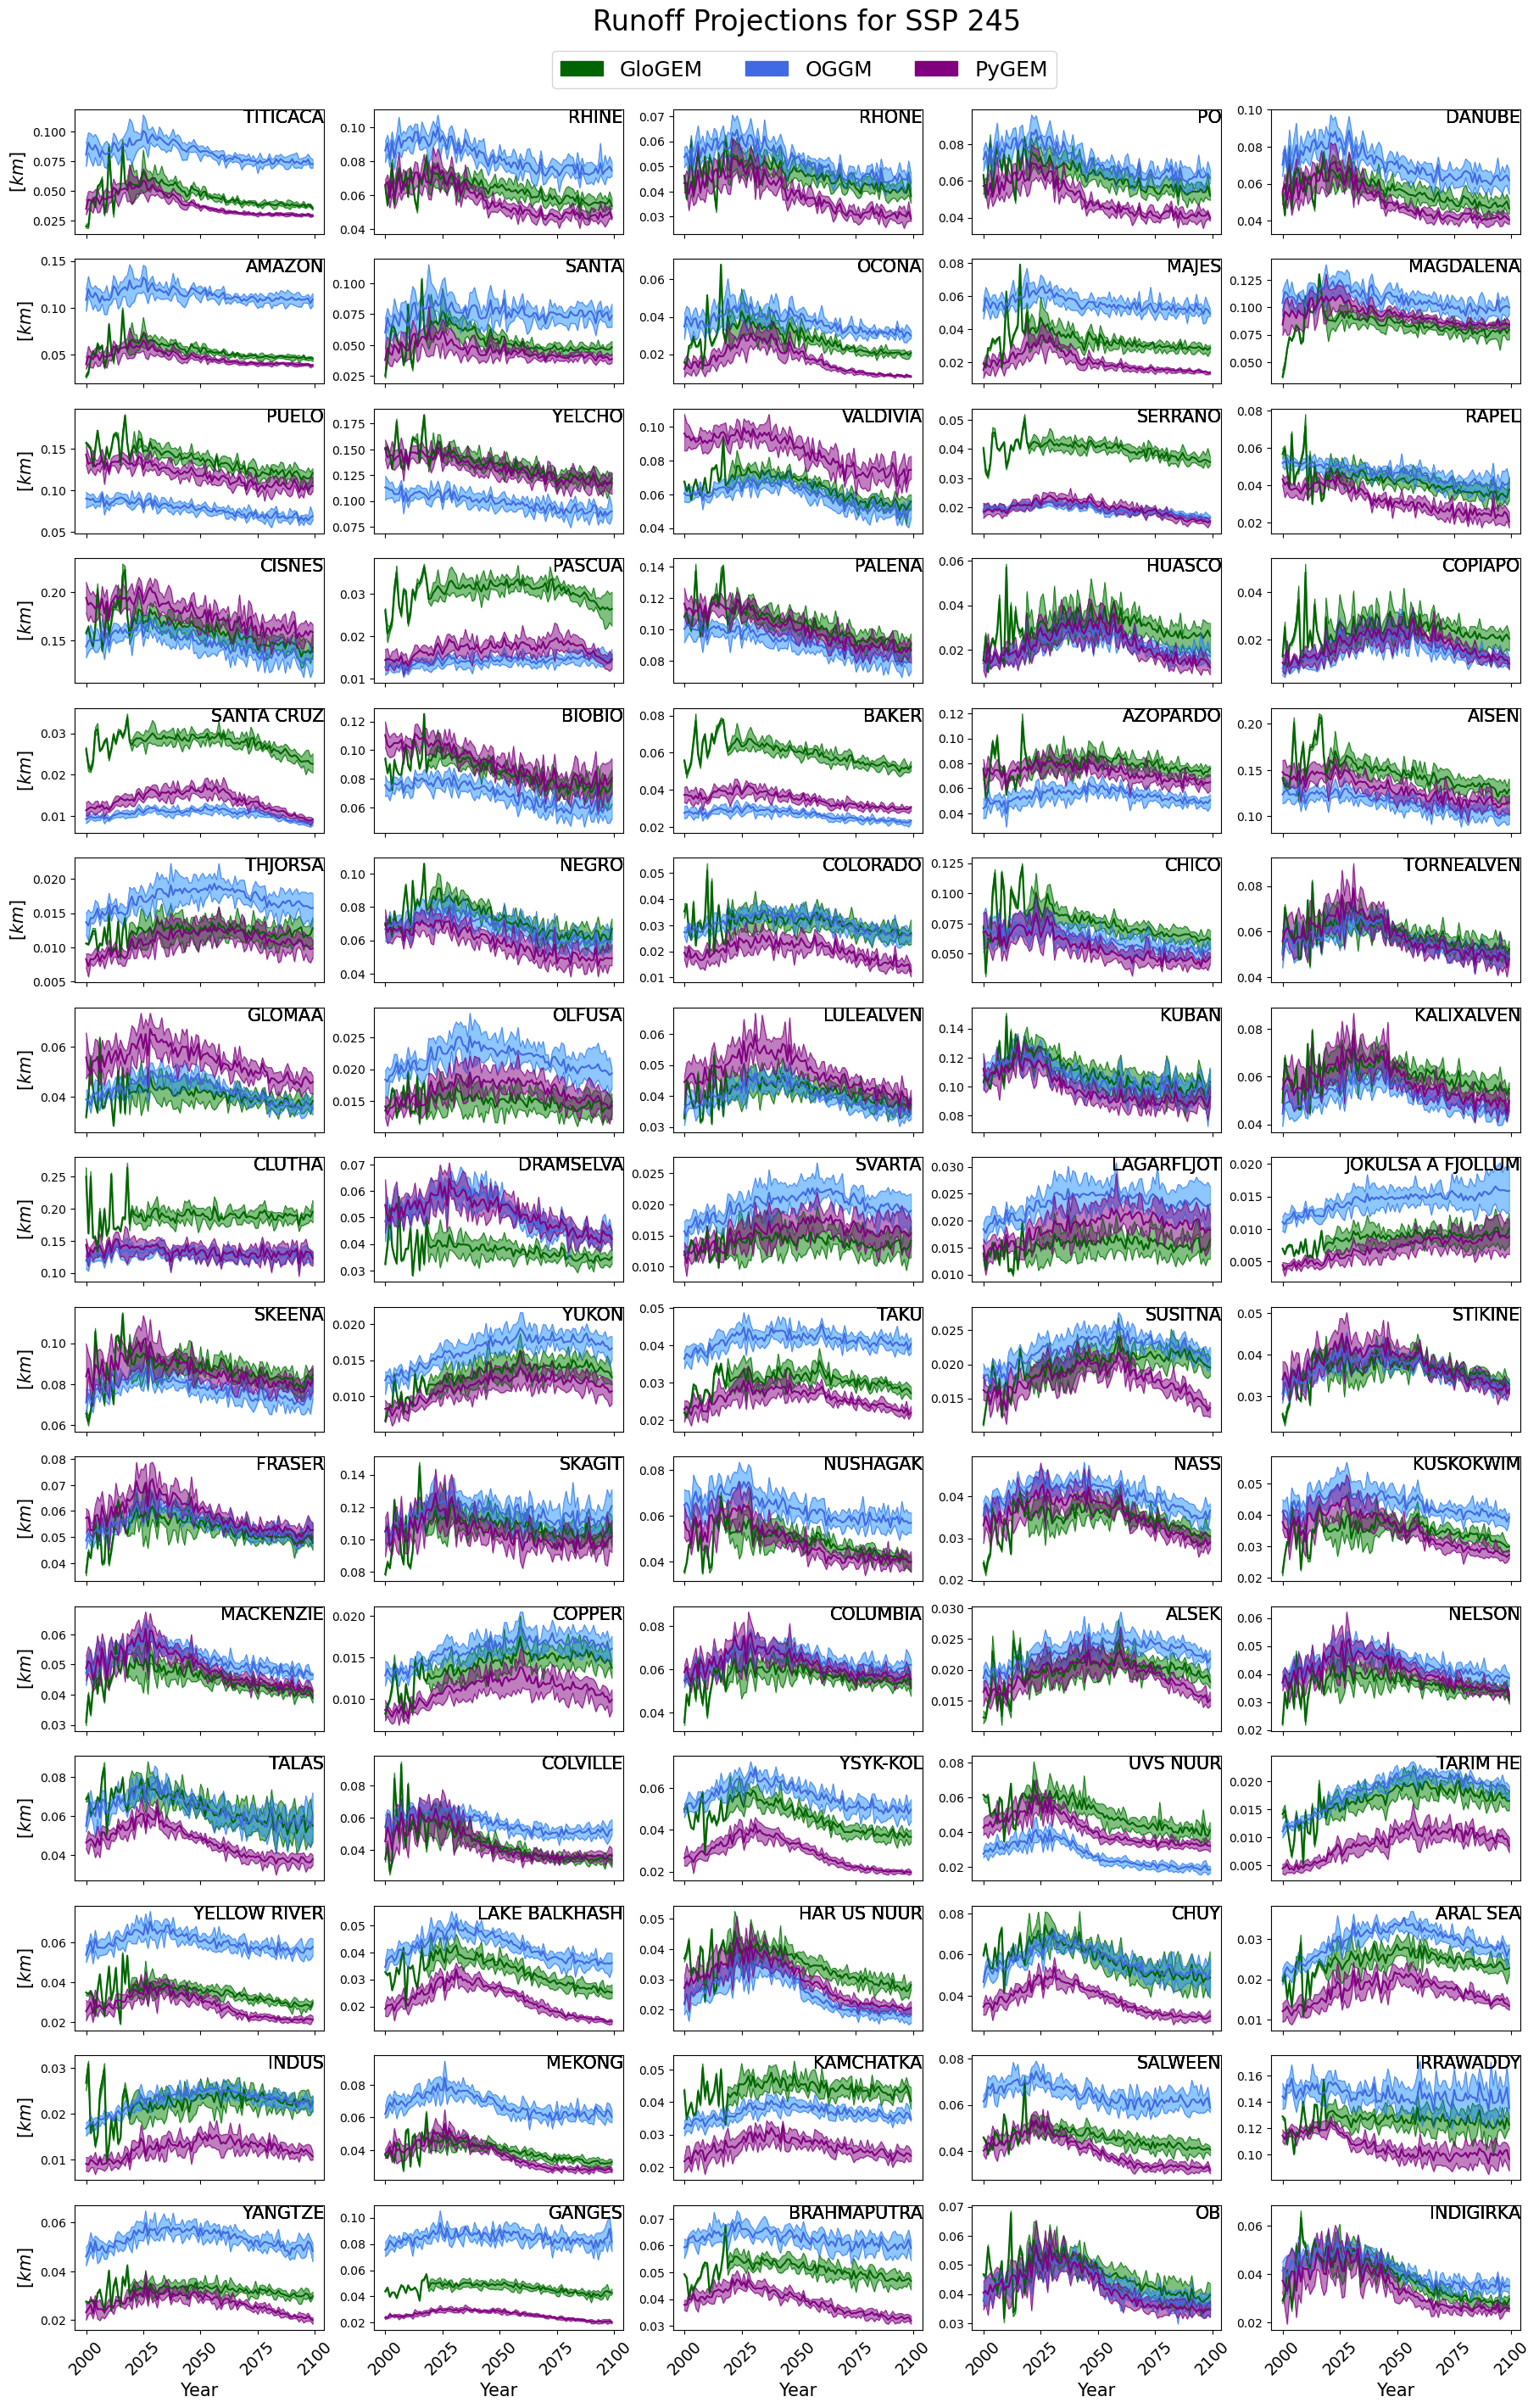

In [32]:
#import matplotlib.ticker as ticker

#Examing our smoothed datasets and the assigned peak water times
num_rows = 15
num_cols = 5

SSP = 'ssp245'
SSPnum = SSP[-3::]

def calculate_ticks_range(min_val, max_val, num_ticks=3):
    if max_val - min_val > 3:
        # Round to the nearest integer
        tick_interval = round((max_val - min_val) / (num_ticks - 1))
        ticks = [round(min_val + i * tick_interval) for i in range(num_ticks)]
    else:
        # Use three ticks including the min and max values
        ticks = [round(min_val, 1), round((min_val + max_val) / 2, 1), round(max_val, 1)]
    return ticks

figy, axy = plt.subplots(num_rows, num_cols, figsize=(22, 34))
plt.subplots_adjust(hspace=0.2, wspace=0.2)

row_max_values = []
r = -1
c = 0
for b, basin in enumerate(basins):
    if c % 5 == 0:
        r += 1  
    c = (c + 1) % num_cols
    for g, gmodel in enumerate(gmodels):
        ax = axy[r, c]
        ax.plot(yrs_dt, norm_multi_GCM_mean[gmodel][SSP][basin][0:100], label=gmodel, color=colors[g])
        ax.plot(yrs_dt, norm_GCM_q1[gmodel][SSP][basin][0:100], color=colors[g], linewidth=0.4)
        ax.plot(yrs_dt, norm_GCM_q3[gmodel][SSP][basin][0:100], color=colors[g], linewidth=0.4)
        ax.fill_between(yrs_dt, norm_GCM_q1[gmodel][SSP][basin][0:100], norm_GCM_q3[gmodel][SSP][basin][0:100], color=fill_colors[g], alpha=0.5)
        # Labeling the basin
        ax.text(1, 1, basin, ha='right', va='top', transform=ax.transAxes, fontsize=15)

    # upper_limit = axy[r, c].get_ylim()[1] + 0.15 * (axy[r, c].get_ylim()[1] - axy[r, c].get_ylim()[0])
    # axy[r, c].set_ylim(axy[r, c].get_ylim()[0], upper_limit)

    # # Set the desired number of y-ticks within the data range
    # min_val, max_val = ax.get_ylim()
    # ticks = calculate_ticks_range(min_val, max_val, num_ticks=3)
    # ax.set_yticks(ticks)

    if r == 14:
        ax.set_xlabel('Year', fontsize = 15)
        ax.set_xticks([pd.to_datetime('2000'), pd.to_datetime('2025'), pd.to_datetime('2050'), pd.to_datetime('2075'), pd.to_datetime('2100')],
                      [2000, 2025, 2050, 2075, 2100], rotation=45, fontsize = 13.5)
    else:
        ax.set_xlabel(None)
        ax.set_xticks([pd.to_datetime('2000'), pd.to_datetime('2025'), pd.to_datetime('2050'), pd.to_datetime('2075'), pd.to_datetime('2100')],
                      ['', '', '', '', ''])
    if c == 0:
        ax.set_ylabel(r'$[km]$', fontsize = 15)

green_patch = mpatches.Patch(color='darkgreen', label='GloGEM')
blue_patch = mpatches.Patch(color='royalblue', label='OGGM')
purple_patch = mpatches.Patch(color='purple', label='PyGEM') 
axy[0,0].legend(handles=[green_patch, blue_patch, purple_patch], bbox_to_anchor=(3.98, 1.55), ncol=3, fontsize = 18)

plt.suptitle(f"Runoff Projections for SSP {SSPnum} ", x=0.52, y=0.915, fontsize = 24)

plt.savefig(f"/Users/finnwimberly/Desktop/Lizz Research/AGU Figures/RF_VolNormalized_{SSP}.png", dpi=300, bbox_inches='tight')
plt.show()

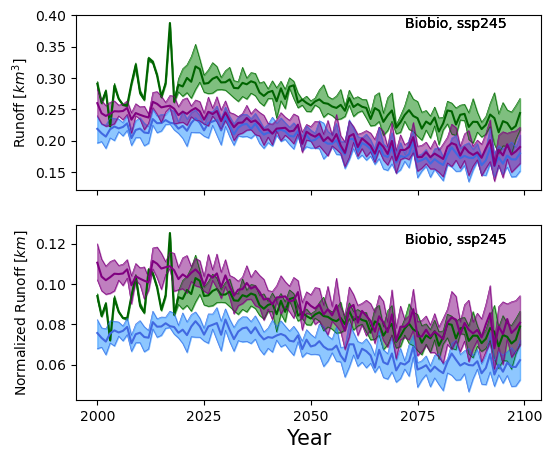

In [58]:
# Input a single basin name
basin = 'BIOBIO'
basinstext = 'Biobio'

SSP = 'ssp245'

# Create a 1-row, 4-column subplot arrangement
fig, axs = plt.subplots(2, 1, figsize=(6, 5), sharex=True)
plt.subplots_adjust(hspace=0.2, wspace=0.25)


for g, gmodel in enumerate(gmodels):
    ax = axs[0]
    ax.plot(yrs_dt, multi_GCM_mean[gmodel][SSP][basin][0:100], label=gmodel, color=colors[g])
    ax.plot(yrs_dt, GCM_q1[gmodel][SSP][basin][0:100], color=colors[g], linewidth=0.4)
    ax.plot(yrs_dt, GCM_q3[gmodel][SSP][basin][0:100], color=colors[g], linewidth=0.4)
    ax.fill_between(yrs_dt, GCM_q1[gmodel][SSP][basin][0:100], GCM_q3[gmodel][SSP][basin][0:100], color=fill_colors[g], alpha=0.5)
    ax.set_xlabel('', fontsize = 15)
    ax.set_xticks([pd.to_datetime('2000'), pd.to_datetime('2025'), pd.to_datetime('2050'), pd.to_datetime('2075'), pd.to_datetime('2100')],
                      [2000, 2025, 2050, 2075, 2100], fontsize = 10)
    ax.set_ylabel(r'Runoff $[km^3]$', fontsize = 10)
    ax.text(pd.to_datetime('2072'), 0.38, f"{basinstext}, {SSP}", fontsize = 10)


    ax = axs[1]
    ax.plot(yrs_dt, norm_multi_GCM_mean[gmodel][SSP][basin][0:100], label=gmodel, color=colors[g])
    ax.plot(yrs_dt, norm_GCM_q1[gmodel][SSP][basin][0:100], color=colors[g], linewidth=0.4)
    ax.plot(yrs_dt, norm_GCM_q3[gmodel][SSP][basin][0:100], color=colors[g], linewidth=0.4)
    ax.fill_between(yrs_dt, norm_GCM_q1[gmodel][SSP][basin][0:100], norm_GCM_q3[gmodel][SSP][basin][0:100], color=fill_colors[g], alpha=0.5)
    ax.set_xlabel('Year', fontsize = 15)
    ax.set_xticks([pd.to_datetime('2000'), pd.to_datetime('2025'), pd.to_datetime('2050'), pd.to_datetime('2075'), pd.to_datetime('2100')],
                      [2000, 2025, 2050, 2075, 2100], fontsize = 10)
    ax.set_ylabel(r'Normalized Runoff $[km]$', fontsize = 10)
    ax.text(pd.to_datetime('2072'), 0.12, f"{basinstext}, {SSP}", fontsize = 10)


# Legend
green_patch = mpatches.Patch(color='darkgreen', label='GloGEM')
purple_patch = mpatches.Patch(color='purple', label='PyGEM')
blue_patch = mpatches.Patch(color='royalblue', label='OGGM')
#axs[0].legend(handles=[green_patch, purple_patch, blue_patch], bbox_to_anchor=(3.15, 1.2), ncol=3)

# Titles
#plt.suptitle('Original and Normalized Runoff Projections for Skagit River Basins', x=0.5, y=0.9)
# Show the plot
plt.savefig(f"/Users/finnwimberly/Desktop/Lizz Research/Paper Figs/VolNorm_{basinstext}.png", dpi=450, bbox_inches='tight')


plt.show()